*2026 Spring DSAA 2011 Maching Learning*
## Lab Note 11
*Jing XU, Changkai MAI, Chunming MA, Kaiwei YANG*  
*Hong Kong University of Science and Technology (Guangzhou)*

**Question 1.** GMM

Please load the `DSAA2011-LA11-data.csv` file to obtain the dataset, then complete the following tasks.  

**Task**  
1. Please implement a GMM (Gaussian Mixture Model) algorithm to cluster the dataset.
2. Please use scikit-learn to implement K-Means, DBSCAN, hierarchical clustering, and GMM for clustering analysis
3. Visualize and compare the performance of all four clustering methods using plots.

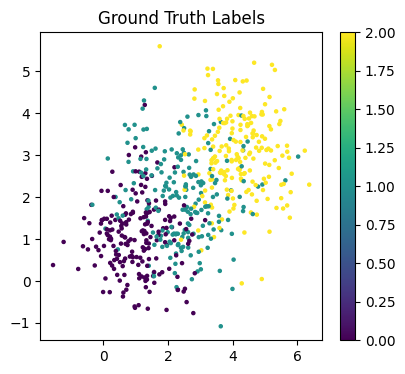

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Read data (assume CSV with x,y,label)
data = pd.read_csv('DSAA2011-LA11-data.csv', sep='\t')
data = data['x,y,label'].str.split(',', expand=True)
data.columns = ['x', 'y', 'label']
data['x'] = data['x'].astype(float)
data['y'] = data['y'].astype(float)
true_labels = data['label'].astype(int).values
X = data[['x', 'y']].values

# Plot original data (by ground truth labels)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=true_labels, s=5, cmap='viridis')
plt.title("Ground Truth Labels")
plt.colorbar()

In [3]:
class GMM:
    def __init__(self, n_components, max_iter=100, tol=1e-4):
        self.K = n_components
        self.max_iter = max_iter
        self.tol = tol
        
    def fit(self, X):
        # Initialize parameters
        n, d = X.shape
        self.weights = np.ones(self.K) / self.K
        self.means = X[np.random.choice(n, self.K, replace=False)]
        self.covs = [np.eye(d)] * self.K
        
        log_likelihood = 0
        for _ in range(self.max_iter):
            # E-step: compute responsibilities
            gamma = np.zeros((n, self.K))
            for k in range(self.K):
                gamma[:, k] = self.weights[k] * self._gaussian_pdf(X, self.means[k], self.covs[k])
            gamma /= gamma.sum(axis=1, keepdims=True)
            
            # M-step: update parameters
            Nk = gamma.sum(axis=0)
            self.weights = Nk / n
            self.means = np.dot(gamma.T, X) / Nk[:, None]
            for k in range(self.K):
                diff = X - self.means[k]
                self.covs[k] = (gamma[:, k] * diff.T) @ diff / Nk[k]
                
            # Check convergence
            new_log_likelihood = np.sum(np.log(np.sum([self.weights[k] * self._gaussian_pdf(X, self.means[k], self.covs[k]) 
                                                       for k in range(self.K)], axis=0)))
            if np.abs(new_log_likelihood - log_likelihood) < self.tol:
                break
            log_likelihood = new_log_likelihood
            
    def _gaussian_pdf(self, X, mean, cov):
        # Compute multivariate Gaussian PDF
        n, d = X.shape
        det = np.linalg.det(cov)
        inv = np.linalg.inv(cov)
        norm = 1 / (np.sqrt((2 * np.pi)**d * det))
        exp = np.exp(-0.5 * np.sum((X - mean) @ inv * (X - mean), axis=1))
        return norm * exp
    def predict(self, X):
        """Predict cluster labels"""
        gamma = np.zeros((len(X), self.K))
        for k in range(self.K):
            gamma[:, k] = self.weights[k] * self._gaussian_pdf(X, self.means[k], self.covs[k])
        return np.argmax(gamma, axis=1)

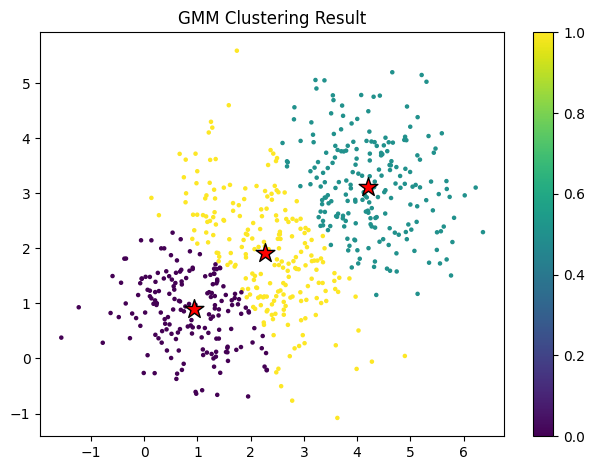

In [4]:
# Clustering Application
# Question 1.1
gmm = GMM(n_components=3)
gmm.fit(X)
pred_labels = gmm.predict(X)
# Plot GMM clustering result
import matplotlib.pyplot as plt
plt.subplot(1, 1, 1)
plt.scatter(X[:, 0], X[:, 1], c=pred_labels, s=5, cmap='viridis')
plt.scatter(np.array(gmm.means)[:, 0], np.array(gmm.means)[:, 1], 
            s=200, marker='*', c='red', edgecolor='black')
plt.title("GMM Clustering Result")
plt.colorbar()
plt.tight_layout()
plt.show()

/home/xujing/miniconda3/envs/llava-hr/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


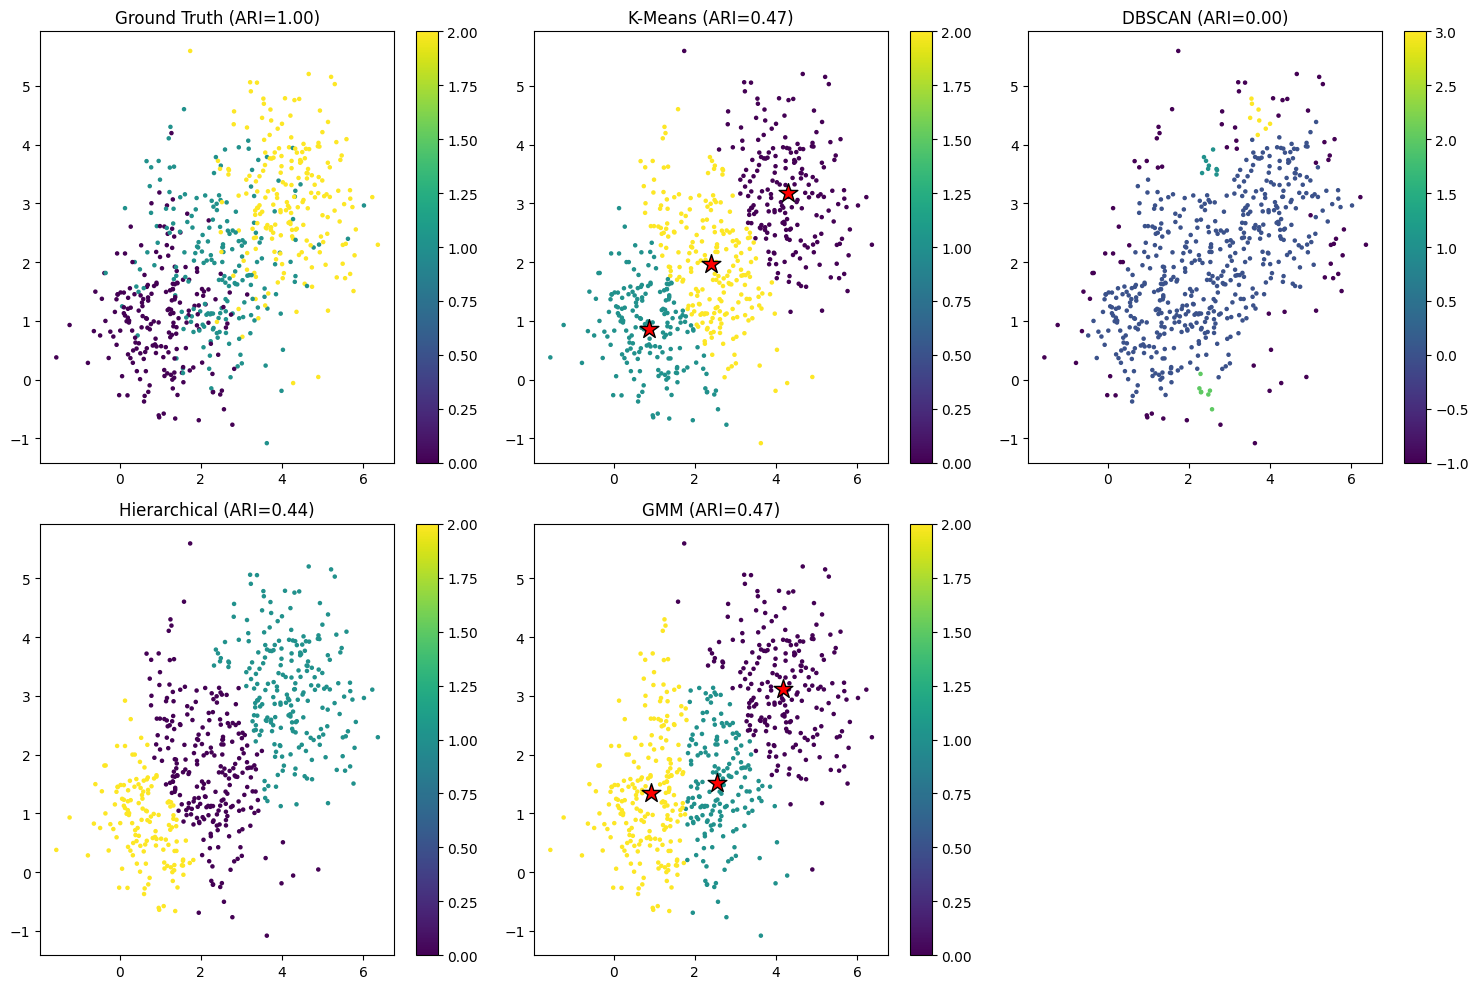

In [5]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
# Four Clustering Methods
# Question 1.2
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
dbscan = DBSCAN(eps=0.3, min_samples=5).fit(X)
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X)
gmm = GaussianMixture(n_components=3, random_state=42).fit(X)

# Visualization and Comparison
# Question 1.3
plt.figure(figsize=(15, 10))
titles = ["Ground Truth", "K-Means", "DBSCAN", "Hierarchical", "GMM"]
labels_list = [true_labels, kmeans.labels_, dbscan.labels_, hierarchical.labels_, gmm.predict(X)]

for i, (title, labels) in enumerate(zip(titles, labels_list)):
    plt.subplot(2, 3, i+1)
    sc = plt.scatter(X[:, 0], X[:, 1], c=labels, s=5, cmap='viridis')
    if title == "K-Means":
        plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                    s=200, marker='*', c='red', edgecolor='black')
    elif title == "GMM":
        plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], 
                    s=200, marker='*', c='red', edgecolor='black')
    plt.title(f"{title} (ARI={adjusted_rand_score(true_labels, labels):.2f})")
    plt.colorbar(sc)

plt.tight_layout()
plt.show()

**Question 2.** Dimensionality Reduction with PCA

**PCA goal**: Find orthogonal transformation $W$ of centered data $X_c$ (i.e. $Y=WX_c$) such that variance along subsequent components is maximized (i.e. most variance along first, etc.); note $X_c$ is $n \times p$, $W$ is $p \times p$, $Y$ is $n \times p$, principal components are the columns of $W$
1. **Input**: $X \in \mathbb{R}^{n \times p}$ ($n$ samples, $p$ features).

2. **Standardize the Data**: Scale features to zero mean and unit variance:  
   $$ X_k \leftarrow \frac{X_k - \mu_k}{\sigma_k} $$
   or
   $$ X \leftarrow (V^{1/2})^{-1} (X - \mu) $$
   where $\mu_k$ and $\sigma_k$ are the mean and standard deviation of feature $k$, and $V^{1/2}$ is a diagonal matrix of standard deviations.

3. **Compute Covariance Matrix**: Calculate  
   $$ \Sigma = \frac{1}{n} X'^\top X' $$
   where $X'$ is the standardized data matrix.

4. **Eigenvalue Decomposition**: Perform eigendecomposition of $\Sigma$:  
   $$ \Sigma = W \Lambda W^\top $$
   - Eigenvectors (columns of $W$) are the **principal components**.  
   - Eigenvalues (diagonal entries of $\Lambda$) represent explained variances.

5. **Select Principal Components**: Choose the top $k$ eigenvectors corresponding to the largest eigenvalues (e.g., retain components that capture 95% of total variance).

6. **Project Data**: Transform data into the lower-dimensional space:  
   $$ Z = X' W_k $$
   where $W_k$ is the matrix of selected eigenvectors (size $p \times k$).

**Tasks: Complete PCA Implementation** 
1. Center data, i.e. first subtract the mean from the data
2. Compute the covariance matrix
3. Compute eigenvectors and order them in terms of decreasing eigenvalues
4. Transform the data using these eigenvectors
5. Compare to library PCA implementation

In [6]:
# load libraries
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load data
iris = load_iris()
X = iris.data
y = iris.target
print(f"{X[:5]=}, \n{y[:5]=}")

X[:5]=array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]]), 
y[:5]=array([0, 0, 0, 0, 0])


In [7]:
def manual_pca(X, n_components=2, scale=True):
    # Standardization
    # Solution 1.1
    X_centered = X - np.mean(X, axis=0)
    
    # Scaling
    if scale:
        X_centered /= np.std(X_centered, axis=0, ddof=1)
        
    # Covariance matrix
    # Solution 1.2
    cov_matrix = (X_centered.T @ X_centered) / (X.shape[0]-1)
    
    # Eigen decomposition
    # Solution 1.3: compute the eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Solution 1.3: order the eigen vectors
    sorted_indices = np.argsort(eigenvalues)[::-1]

    # Select the eigenvectors 
    components = eigenvectors[:, sorted_indices[:n_components]] 

    # Solution 1.4
    return X_centered @ components, components

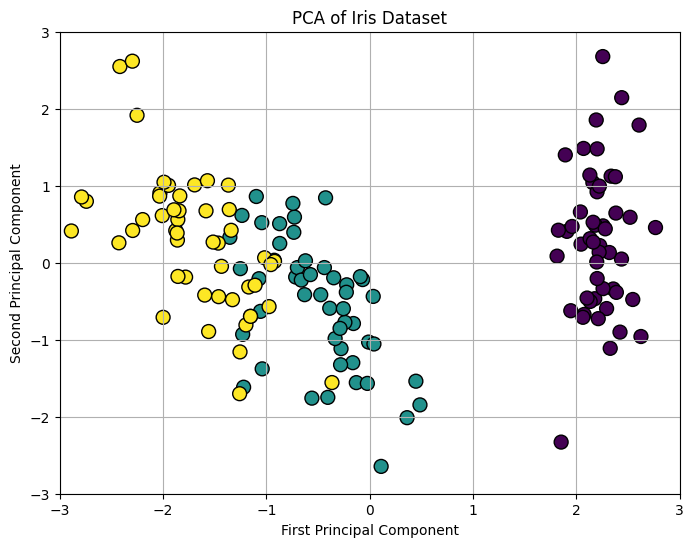

In [11]:
# obatin the principal components
X_pca, components = manual_pca(X, n_components=2)

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=100)
plt.title("PCA of Iris Dataset")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.grid()
plt.show()

PCA Error: 2.1363093675045333e-05


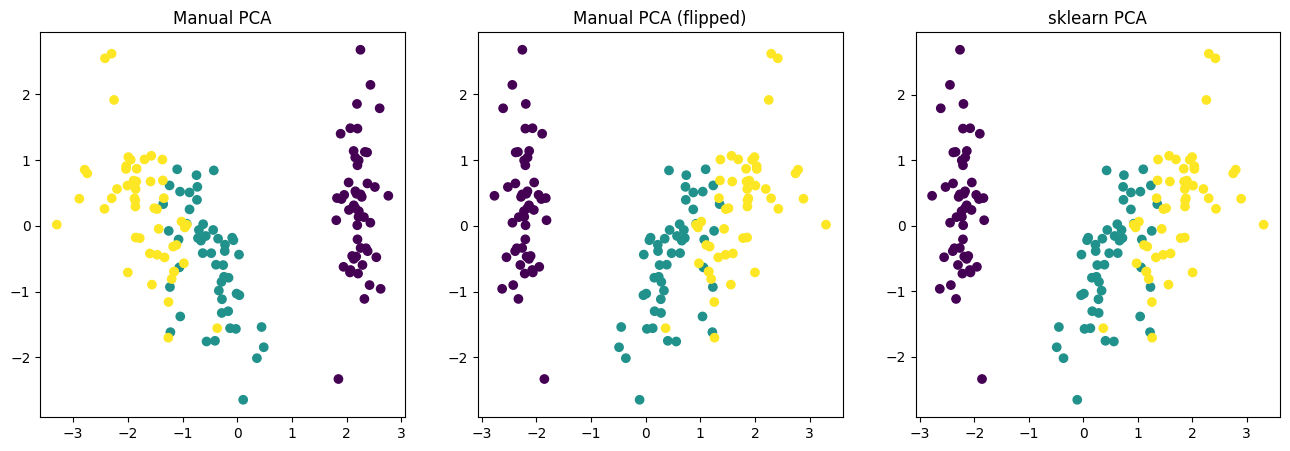

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize the data
X_std = StandardScaler().fit_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X_std)

X_pca_manual, _ = manual_pca(X, n_components=2)
# Plot comparison
plt.figure(figsize=(16,5))
plt.subplot(131)
plt.scatter(X_pca_manual[:,0], X_pca_manual[:,1], c=y)
plt.title("Manual PCA")

# if you want to see the same orientation, you can flip the sign
manual_pca_aligned = X_pca_manual.copy()
sign0 = np.sign(X_pca_manual[:,0] * X_pca_sklearn[:,0])
sign1 = np.sign(X_pca_manual[:,1] * X_pca_sklearn[:,1])
manual_pca_aligned[:, 0] = X_pca_manual[:, 0] * sign0
manual_pca_aligned[:, 1] = X_pca_manual[:, 1] * sign1
plt.subplot(132)
plt.scatter(manual_pca_aligned[:,0], manual_pca_aligned[:,1], c=y) 
plt.title("Manual PCA (flipped)")

plt.subplot(133)
plt.scatter(X_pca_sklearn[:,0], X_pca_sklearn[:,1], c=y)
plt.title("sklearn PCA")


pca_error = np.mean((X_pca_sklearn - manual_pca_aligned) ** 2)
print("PCA Error:", pca_error)

**Question 3.** Multidimensional Scaling (MDS)

**Input**: Proximity matrix $D \in \mathbb{R}^{n \times n}$, where $\delta_{ij}$ represents the distance between samples $i$ and $j$.  
**Goal**: Find a lower-dimensional embedding $Z \in \mathbb{R}^{n \times k}$ such that $\|z_i - z_j\| \approx \delta_{ij}$ for all $i,j$.  
**Steps:**
1. **Compute the Squared Proximity Matrix**  
   Calculate the matrix of squared distances:  
   $$
   D^{(2)} = \left( d_{ij}^2 \right) \in \mathbb{R}^{n \times n},
   $$  
   where $d_{ij}$ is the distance between samples $i$ and $j$.

2. **Double Centering to Construct $B$**  
   Transform $D^{(2)}$ into the Gram matrix $B$ using:  
   $$
   B = -\frac{1}{2} J D^{(2)} J,
   $$  
   where $J$ is the centering matrix:  
   $$
   J = I - \frac{1}{n} \mathbf{1} \mathbf{1}^\top,
   $$  
   - $I$: Identity matrix of size $n \times n$,  
   - $\mathbf{1}$: Column vector of ones,  
   - $n$: Number of samples.

3. **Eigenvalue Decomposition**  
   Compute the **$k$ largest eigenvalues $\lambda_1, \ldots, \lambda_k$** and their corresponding **eigenvectors $e_1, \ldots, e_k$** from $B$:  
   $$
   B = E \Lambda E^\top,
   $$  
   - $E = [e_1, \ldots, e_n]$: Matrix of eigenvectors,  
   - $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_n)$: Diagonal matrix of eigenvalues.

4. **Construct Low-Dimensional Coordinates**  
   Extract the embedding $Y \in \mathbb{R}^{n \times k}$ using:  
   $$
   Y = E_k \Lambda_k^{1/2},
   $$  
   - $E_k = [e_1, \ldots, e_k]$: Top-$k$ eigenvectors (size $n \times k$),  
   - $\Lambda_k^{1/2} = \text{diag}(\sqrt{\lambda_1}, \ldots, \sqrt{\lambda_k})$: Square roots of the top-$k$ eigenvalues.

**Tasks: Complete Metric MDS Implementation**
1. Euclidean distance matrix calculation
2. Double centering procedure
3. Eigenvalue handling
4. Compare with sklearn's MDS

In [15]:
from sklearn.manifold import MDS

def manual_mds(D, n_components=2):
    # Double centering
    # Suppose D is the matrix of distances
    # Solution 2.2, double centering, first set the centering matrix H:
    H = np.eye(D.shape[0]) - np.ones(D.shape)/D.shape[0]
    # Solution 2.2, then transform D into gram matrix B:
    B = -0.5 * H @ (D**2) @ H
    
    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(B)
    
    # Eigenvalue handling
    eigenvalues = np.clip(eigenvalues, 0, None)
    # Solution 2.3
    indices = np.argsort(eigenvalues)[::-1][:n_components]
    
    return eigenvectors[:, indices] @ np.diag(np.sqrt(eigenvalues[indices]))

Text(0.5, 1.0, 'Sklearn MDS')

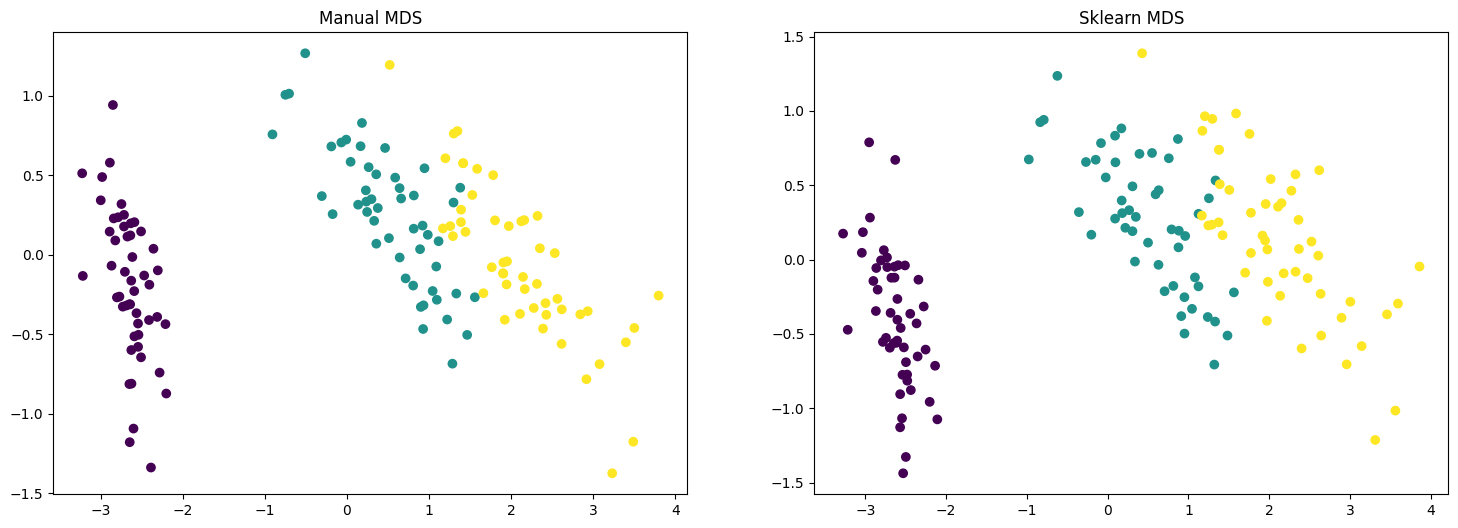

In [16]:
# Execution and validation
from sklearn.metrics import pairwise_distances
euclidean_dist = pairwise_distances(X, metric='euclidean')

X_mds_manual = manual_mds(euclidean_dist)
X_mds_sk = MDS(
    n_components=2,
    dissimilarity='precomputed',
    normalized_stress=False,
    random_state=42,
    max_iter=500,
    eps=1e-9
).fit_transform(euclidean_dist)

# Plot comparison
plt.figure(figsize=(18,6))
plt.subplot(121)
plt.scatter(X_mds_manual[:,0], X_mds_manual[:,1], c=y, cmap='viridis')
plt.title('Manual MDS')

plt.subplot(122)
plt.scatter(X_mds_sk[:,0], X_mds_sk[:,1], c=y, cmap='viridis')
plt.title('Sklearn MDS')